In [1]:
# %%
import os
from xspec import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
import h5py
from scipy.stats import chi2 as chi2_scipy
import sys  
from scipy.ndimage import uniform_filter1d
from datetime import datetime
from scipy.stats import chi2

In [2]:
Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar
Fit.query = "yes"  # automatically answer "yes" to prompts

In [3]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_5deg/srctoolout_000_SourceProducts_00001_5deg_rebin80/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
fileIBLineTM1="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM1.txt"
Energy_width_TM1 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM1.csv"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
fileIBLineTM2="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM2.txt"
Energy_width_TM2 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM2.csv"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
fileIBLineTM3="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM3.txt"
Energy_width_TM3 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM3.csv"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
fileIBLineTM4="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM4.txt"
Energy_width_TM4 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM4.csv"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
fileIBLineTM5="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM5.txt"
Energy_width_TM5 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM5.csv"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
fileIBLineTM6="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM6.txt"
Energy_width_TM6 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM6.csv"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
fileIBLineTM7="/Users/marcotaoso/Documents/2024/eROSITA/xSpec/LMC_5deg/Fit_global/IBLine_Globalfit_TM7.txt"
Energy_width_TM7 = "/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width/Energ_Width_TM7.csv"

In [4]:
# Define telescope file mappings
telescope_files = {
    "TM1": (filespectrumTM1, fileRMFTM1, fileARFTM1, fileIBLineTM1, Energy_width_TM1),
    "TM2": (filespectrumTM2, fileRMFTM2, fileARFTM2, fileIBLineTM2, Energy_width_TM2),
    "TM3": (filespectrumTM3, fileRMFTM3, fileARFTM3, fileIBLineTM3, Energy_width_TM3),
    "TM4": (filespectrumTM4, fileRMFTM4, fileARFTM4, fileIBLineTM4, Energy_width_TM4),
    "TM5": (filespectrumTM5, fileRMFTM5, fileARFTM5, fileIBLineTM5, Energy_width_TM5),
    "TM6": (filespectrumTM6, fileRMFTM6, fileARFTM6, fileIBLineTM6, Energy_width_TM6),
    "TM7": (filespectrumTM7, fileRMFTM7, fileARFTM7, fileIBLineTM7, Energy_width_TM7),
    "ALL": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM5, filespectrumTM6, filespectrumTM7],
            [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM5, fileRMFTM6, fileRMFTM7],
            [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM5, fileARFTM6, fileARFTM7],
            [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM5, fileIBLineTM6, fileIBLineTM7],
            [Energy_width_TM1, Energy_width_TM2, Energy_width_TM3, Energy_width_TM4, Energy_width_TM5, Energy_width_TM6, Energy_width_TM7]),
    "ALL_CLEAN": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM6],
    [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM6],
    [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM6],
    [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM6],
    [Energy_width_TM1, Energy_width_TM2, Energy_width_TM3, Energy_width_TM4, Energy_width_TM6])
}

In [5]:
telescope = "TM1"

In [6]:
# Set the file arrays based on telescope selection
if telescope in telescope_files:
    if telescope == "ALL":
        vfilespectrum, vfileRMF, vfileARF, vfileIBLine, vEnergyWidth = telescope_files[telescope]
    else:
        spectrum_file, rmf_file, arf_file, ibline_file, energy_width_file = telescope_files[telescope]
        vfilespectrum = [spectrum_file]
        vfileRMF = [rmf_file]
        vfileARF = [arf_file]
        vfileIBLine = [ibline_file]
        vEnergyWidth = [energy_width_file]
    print(f"Using telescope: {telescope}")
    print(f"Number of telescopes: {len(vfilespectrum)}")
else:
    print(f"Error: Unknown telescope '{telescope}'. Valid options: TM1, TM2, TM3, TM4, TM5, TM6, TM7, ALL_CLEAN")
    sys.exit(1)

Using telescope: TM1
Number of telescopes: 1


In [7]:
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_5deg/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 3.608e+05 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_5deg/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Ch

Error: cannot read response file srctoolout_120_RMF_00001.fits


In [8]:
data = np.loadtxt(vEnergyWidth[0], usecols=(0, 1))
sorted_data = data[np.argsort(data[:, 0])]
data = sorted_data
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.424 #keV 2.103 1.424 1.206
Eline = float(Eline)

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)

#Emin= Eline - 5*sigma
#Emax= Eline + 5*sigma
#if(Emin<Eallmin):
#   Emin=Eallmin
#if(Emax>Eallmax):
#    Emax=Eallmax

Emin= 1.0
Emax= 2.2

print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)

Eline  1.424  sigma  0.03275626656133249
Emin  1.0  Emax  2.2
**-1.0,,2.2-**
   151 channels (1-151) ignored in spectrum #     1
   728 channels (297-1024) ignored in spectrum #     1



In [9]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))

Plot command list is now empty
NEbins  145
***************
Selected values  1.009747564792633   2.1905583143234253  Nbins  145
***************
Min Max counts  260   799


In [10]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.03275626656133249
DeltaE  [0.00714338 0.00715828 0.00717354 0.00718868 0.00720382 0.00721908
 0.0072341  0.00724936 0.00726438 0.00727952 0.00729477 0.00730956
 0.00732481 0.00734007 0.00735509 0.00737    0.00738537 0.00740016
 0.00741541 0.00743043 0.00744545 0.00746047 0.0074755  0.00749063
 0.00750554 0.00752056 0.00753582 0.00755072 0.00756538 0.00758052
 0.00759578 0.00761044 0.00762546 0.00764036 0.00765538 0.00767028
 0.0076853  0.00769997 0.00771487 0.00773001 0.00774455 0.00775969
 0.00777435 0.00778937 0.00780416 0.00781882 0.00783372 0.00784874
 0.00786304 0.00787818 0.00789273 0.00790751 0.00792241 0.00793695
 0.00795162 0.00796652 0.00798094 0.00799584 0.00801039 0.00802505
 0.00803959 0.00805438 0.00806868 0.00808346 0.00809801 0.00811267
 0.00812697 0.00814152 0.00815618 0.00817049 0.00818515 0.00819945
 0.00821412 0.00822842 0.00824273 0.00825703 0.00827169 0.00828588
 0.00830019 0.00831449 0.00832915 0.00834298 0.00835752 0.00837159
 0.0083859  0.00840032 0.00

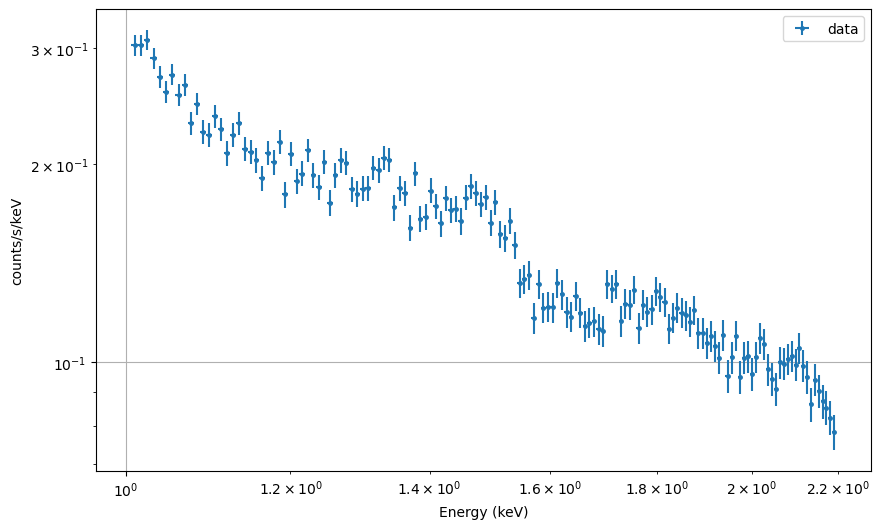

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [12]:
#EminL = Eline - 7*sigma
#EmaxL = Eline + 7*sigma
#if(EminL<Eallmin):
#    EminL = Eallmin
#if(EmaxL>Eallmax):
#    EmaxL = Eallmax

EminL = Emin
EmaxL = Emax

if isinstance(vfileIBLine, list):
    ib_file = vfileIBLine[0]
else:
    ib_file = vfileIBLine

# Load IB lines
data = np.loadtxt(ib_file, skiprows=0)
IBenergy = data[:,0]
#IBenergymin = data[:,2]
#IBenergymax = data[:,5]
IBenergymin = data[:,0]-0.025
IBenergymax = data[:,0]+0.025
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/AstroLines/LMC_3deg/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]


ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  1
[1.47993634]
[1.45493634]   [1.50493634]


In [13]:
# %%
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers, keyfits):
        """
        Set parameter values and limits.
        keyfits[i] == True  → parameter is free
        keyfits[i] == False → parameter is frozen
        """
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            step = float(np.abs(1e-2*a))
            # for frozen parameters
            if not keyfits[i]:
                # --- Frozen parameter: safe assignment (no step, identical limits)
                param.values = [a, step, b, b, c, c]
                param.frozen = True
                continue

            param.values = [a, step, b, b, c, c]
            param.frozen = False

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [14]:
# %%
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [15]:
# %%
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

In [16]:
TSth = 2.71
def MTroots(vx,vy):
    vroots = []
    for i in range(1,len(vx)):
        #print("vx ",vx[i]," ",vy[i])
        #Check whether sign has changed
        if(vy[i]*vy[i-1]<0.):
            root=(vx[i]*vy[i-1]-vx[i-1]*vy[i])/(vy[i-1]-vy[i])
            #print(vx[i-1]," ",vx[i]," ",vy[i-1]," ",vy[i])
            #print("i ", i," ",root," ")
            vroots.append(root)
    return  vroots

def chi2approx(fullmodel_xp, params_fit, params_name_fit, params_target_fit, A):
    # Change DM normalization
    params_inside = params_fit
    change_param_value(params_inside, params_name_fit, params_target_fit, "gaussian", "norm", A)
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)
    # evaluation
    ### MT: no need to fix DM line norm since here I just do an evaluation, not a fit
    res = mymodel_fit.evaluate_folded(params_inside)
    #print("A ",A," TS ",res)
    #PrintModelXspec()
    #Check the model!
    #Xset.chatter = 10
    #AllModels.show()
    #Xset.chatter = 1
    return res

def ApproximateBound(model_final, DMbf, normlDMhdata2, nstepsDM, TS_all, params_fit, params_name_fit, params_target_fit):
    start = np.max(np.array([DMbf,normlDMhdata2*1e-5]))
    end = normlDMhdata2
    profile_range = np.logspace(np.log10(start), np.log10(end), num = nstepsDM)
    TS_vals = np.zeros_like(profile_range)
    for i, A in enumerate(profile_range):
        TS_vals[i] = chi2approx(model_final, params_fit, params_name_fit, params_target_fit, A)
        #print("A TS ",A," ",TS_vals[i])
    x = np.log10(profile_range)
    y = TS_vals - TS_all - TSth
    vroots = np.pow(10.,MTroots(x,y))
    if(len(vroots)>0):
        bound_approx=np.max(vroots)
    else:
        bound_approx=0.
    return bound_approx

def BoundProfiling(profile_range, delta_TS):
    x = np.log10(profile_range)
    y = delta_TS - TSth
    vroots = np.pow(10.,MTroots(x,y))
    if(len(vroots)>0):
        bound=np.max(vroots)
    else:
        bound=0.
    return bound
    
def PrintModelXspec():
    for _name in m_mw.componentNames:
        _comp = m_mw.__getattribute__(_name)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            print(_name," ",_pname," ",_par.values)
    print(params_name_pb[0]," ",params_target_pb[0]," ",AllModels(1,"mpb").powerlaw.PhoIndex.values)
    print(params_name_pb[1]," ",params_target_pb[1]," ",AllModels(1,"mpb").powerlaw.norm.values)
    for _name in AllModels(1,"mpb").componentNames:
        if _name == "gaussian" or (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
            _comp = AllModels(1,"mpb").__getattribute__(_name)
            for _pname in _comp.parameterNames:
                _par = _comp.__getattribute__(_pname)
                print(_name," ",_pname," ",_par.values)

def freeze_ib_line_energies(freeze=True):
    """Freeze/unfreeze IB Gaussian line energies in mpb model."""
    for name, tgt in zip(params_name_pb, params_target_pb):
        if name.startswith("gaussian") and tgt == "LineE":
            #print("changing")
            change_keyfits(params_name_pb, params_target_pb, keyfits_pb, name, "LineE", not freeze)  # True=free, False=frozen
    mymodel_pb.set_frozen(keyfits_pb)

#def reseed_ib_norms_small():
#    """Re-seed IB Gaussian norms to a small value to avoid bad basins."""
#    for name, tgt in zip(params_name_pb, params_target_pb):
#        if name.startswith("gaussian") and tgt == "norm":
#            change_param_value(params_pb, params_name_pb, params_target_pb, name, "norm", normline_start)
#    mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)

def jitter_params(prev_params, prev_params_lower, prev_params_upper, prev_params_keyfit, rel=0.02):
    """Small multiplicative jitter (±rel) to escape shallow basins."""
    p = np.array(prev_params, dtype=float)
    #eps = (1.0 + rel) ** (2.0*np.random.rand(p.size) - 1.0)
    for i in range(0,len(prev_params)):
        #print(prev_params_keyfit[i]," ",prev_params[i]," ",prev_params_lower[i]," ",prev_params_upper[i])
        if  prev_params_keyfit[i] == True:
            eps = (1.0 + rel) ** (2.0*np.random.rand() - 1.0)
            #print(prev_params_keyfit[i]," ",prev_params[i]," ",prev_params_lower[i]," ",prev_params_upper[i]," ",eps)
            if  (prev_params[i]*eps > prev_params_lower[i])   and   (prev_params[i]*eps < prev_params_upper[i]):
                p[i] = prev_params[i]*eps
            else:
                p[i] = np.random.uniform(prev_params_lower[i], prev_params_upper[i])
                #print("Not to much ")
        else:
            p[i] = prev_params[i]
    return p

def local_predict_ts(logA_prev2, TS_prev2, logA_prev1, TS_prev1, logA_i):
    """Linear extrapolation in log(A) to estimate 'expected' TS."""
    #print("local pred")
    #print(logA_prev2," ",TS_prev2," ",logA_prev1," ",TS_prev1," ",logA_i)
    denom = (logA_prev1 - logA_prev2)
    if denom == 0:
        return TS_prev1
    slope = (TS_prev1 - TS_prev2) / denom
    return TS_prev1 + slope * (logA_i - logA_prev1)


In [17]:
# %%
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See definition of gaussian line in https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/node182.html
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
# normlDMhdata2 = Ratetest*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)

normlDMhdata [counts/keV/s/cm2] 0.1405714623402867
normlDMhdata2 [counts/s/cm2] 0.011542011257120708


In [18]:
# %% [markdown]
# Create the dictionary of the model

# %%

# model 6
#This is a model based on TBabsorption and APEC phenomenological models
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


################################################
#
# Array without _pb are those of the mw model why those with _pb of the pb model
#
###################################################

smallnormlower = 1e-13 # if you want to avoid setting lower limit to zero
smallnorm = 1e-10 # if you want to avoid setting norm to zero

normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = smallnormlower
normline_upper = normlDMhdata2*1000
sigmaDM = Eline*50/3e5 #1e-4
sigma_astrolines = 1e-4
#
#
#power law
startidx = 1.0 #1.4
upperidx = 4.5
loweridx = - 3.0
#
# This normalization should be resonable for PL folded through the ARF
startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
# startpl = 0.05
#upperpl = startpl*1000.0
upperpl = normlDMhdata *np.pow(Eline,upperidx)*100.
lowerpl = smallnormlower
print("startpl ",startpl," upperpl ",upperpl)
#TABS
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
#The foreground Milkyway nH value is cm (https://www.swift.ac.uk/analysis/nhtot/index.php)
# returns 0.3. IN eROSITA LMC paper they have 0.3-0.4 in sources and 8e-2 between SNR
# See also https://ui.adsabs.harvard.edu/abs/2011ApJ...728..159W/abstract (NO arXiv plot is wrong, open published version)
#, LMC is at −32.89, 280.46. I expect NH around few*1e-2
startnH = 6.3e-2 # 6.3e-2 1e22 cm-2 #0.4
# do not allow too crazy values
uppernH = 0.8 #
lowernH = 1.0e-2
#
# APEC https://cxc.cfa.harvard.edu/sherpa/ahelp/xsapec.html
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
startapec = 0.14 # from global fit
upperapec = 80.0
lowerapec = smallnormlower
startT = 0.23 #keV 0.23 0.87
upperT = 3.0 # keV 8.0
lowerT = 0.05
startAb = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
upperAb = 1.0 #5.0
lowerAb = 1.0 #0.01
#
#
# TBABS for DM line: do not leave free
# value from https://heasarc.gsfc.nasa.gov/cgi-bin/Tools/w3nh/w3nh.pl?Entry=LMC&NR=GRB%2FSIMBAD%2BSesame%2FNED&CoordSys=Equatorial&equinox=2000&radius=5.0&usemap=0
nHDM = 0.22
  
model_dic = {
    "TBabs": {
        "TBabs": {
            "nH": pdic(startnH, lowernH, uppernH, True), # (value, lower, upper, key)
            },
            "TBabs_4": {
            "nH": pdic(nHDM, nHDM, nHDM, False), # (value, lower, upper, key)
            }
        },
    "apec": {
        "apec": {
            "kT": pdic(startT, lowerT, upperT, True), # (value, lower, upper, key)
            "Abundanc" : pdic(startAb, lowerAb, upperAb, False),
            "Redshift" : pdic(0., 0., 0., False),
            "norm" : pdic(startapec, lowerapec, upperapec, True)
            }
        },
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, False), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, False)
            }
        },
    "gaussian": {
        "gaussian": {
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False),
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            }
        }
    }
model_dic["_structure"] = f"tbabs*(apec + powerlaw) + tbabs*(gaussian)"
  
  
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
# print(model_dic.values())
#start_index_astrol = sum(
#    len(sub_models) for sub_models in model_dic.values()
#    if isinstance(sub_models, dict)
#)
#start_index_astrol = start_index_astrol + 1
#print("start_index_astrol ",start_index_astrol)

# keep in pb a power law for possible future use. Now I put the norm to zero and all parameters fixed
model_dic_pb = {
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, True)
            }
        },
        "gaussian": {}
    }
#
# Start numbering from start_index_astrol to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    if i == 0:
        g_key = "gaussian"
    else:
        g_key = f"gaussian_{i+2}"  # XSPEC adds suffixes starting at _2
    model_dic_pb["gaussian"][g_key] = {
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], False),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False),
        "norm": pdic(normline_start, normline_lower, normline_upper, True)
    }




# %%
print(model_dic)
print("******")
print(model_dic_pb)

startpl  0.020017376237256825  upperpl  68.97506439365266
{'TBabs': {'TBabs': {'nH': {'value': 0.063, 'lower': 0.01, 'upper': 0.8, 'keyfit': True}}, 'TBabs_4': {'nH': {'value': 0.22, 'lower': 0.22, 'upper': 0.22, 'keyfit': False}}}, 'apec': {'apec': {'kT': {'value': 0.23, 'lower': 0.05, 'upper': 3.0, 'keyfit': True}, 'Abundanc': {'value': 1.0, 'lower': 1.0, 'upper': 1.0, 'keyfit': False}, 'Redshift': {'value': 0.0, 'lower': 0.0, 'upper': 0.0, 'keyfit': False}, 'norm': {'value': 0.14, 'lower': 1e-13, 'upper': 80.0, 'keyfit': True}}}, 'powerlaw': {'powerlaw': {'PhoIndex': {'value': 1.0, 'lower': -3.0, 'upper': 4.5, 'keyfit': False}, 'norm': {'value': np.float64(0.020017376237256825), 'lower': 1e-13, 'upper': np.float64(68.97506439365266), 'keyfit': False}}}, 'gaussian': {'gaussian': {'LineE': {'value': 1.424, 'lower': 1.424, 'upper': 1.424, 'keyfit': False}, 'Sigma': {'value': 0.00023733333333333335, 'lower': 0.00023733333333333335, 'upper': 0.00023733333333333335, 'keyfit': False}, 'nor

In [19]:
# Create the XSpec model
# Create the XSpec model
if "_structure" in model_dic:
    finalM_xp = model_dic["_structure"]
else:
    baseM_parts = []
    for top_key, sub_models in model_dic.items():
        count = len(sub_models)
        baseM_parts.extend([top_key] * count)
    finalM_xp = '+'.join(baseM_parts)

print("mw ", finalM_xp)
AllModels.clear()
m_mw = Model(finalM_xp, "mw", 1)
#
#Add Particle bkg power law
#
# Build model string: one powerlaw + N gaussian components
n_gauss = len(model_dic_pb["gaussian"])
print("n_gauss ",n_gauss)
model_string_pb = "powerlaw"
if n_gauss > 0:
    model_string_pb += " + " + " + ".join(["gaussian"] * n_gauss)
print("mpb model string:", model_string_pb)
model_dic_pb["_structure"] = model_string_pb
AllModels += (model_string_pb, "mpb", 2)

#
print("MPB model components:", [name for name in dir(AllModels(1, "mpb")) if "gaussian" in name])

mw  tbabs*(apec + powerlaw) + tbabs*(gaussian)

Model mw:TBabs<1>(apec<2> + powerlaw<3>) + TBabs<4>*gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   apec       kT         keV      1.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   7    3   powerlaw   norm                1.00000      +/-  0.0          
   8    4   TBabs      nH         10^22    1.00000      +/-  0.0          
   9    5   gaussian   LineE      keV      6.50000      +/-  0.0          
  10    5   gaussian   Sigma      keV      0.100000     +/-  0.0          
  11    5   gaussian   norm                1.00000n_gauss  1
mpb model strin

In [20]:
Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 100000

In [21]:
# Extract the relevant info from the model dictionary
params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)
#
mymodel_mw = MTmodel(model=m_mw, params_name=params_name, params_target=params_target, fit=Fit)
#
# Extract the relevant info from the model dictionary of PB
params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)
#
mymodel_pb = MTmodel(model=AllModels(1,"mpb"), params_name=params_name_pb, params_target=params_target_pb, fit=Fit)
#
#
# set the values including the upper and lower limits in Xspec
mymodel_mw.set_values_all(params, lowers, uppers,keyfits)
# set the free parameters in Xspec
mymodel_mw.set_frozen(keyfits)
#
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb,keyfits_pb)
mymodel_pb.set_frozen(keyfits_pb)

In [22]:



#1.109 TM1
change_param_value(params,params_name, params_target, "TBabs", "nH", 0.6684007239777137)
change_param_value(params,params_name, params_target, "apec", "kT", 0.9035117090190661)
change_param_value(params,params_name, params_target, "apec", "norm", 0.1779065390832923)
change_param_value(params,params_name, params_target, "powerlaw", "PhoIndex", 0.0)
change_param_value(params,params_name, params_target, "powerlaw", "norm",1e-13)
change_param_value(params,params_name, params_target, "gaussian", "norm", 1e-13)
change_param_value(params_pb,params_name_pb, params_target_pb, "powerlaw", "PhoIndex", 1.05191229326254)
change_param_value(params_pb,params_name_pb, params_target_pb, "powerlaw", "norm", 0.19263212296657528)
change_param_value(params_pb,params_name_pb, params_target_pb, "gaussian", "LineE", 1.48676024006377)
change_param_value(params_pb,params_name_pb, params_target_pb, "gaussian", "norm", 0.001511108691826024)



mymodel_mw.set_values_all(params, lowers, uppers, keyfits)
mymodel_mw.set_frozen(keyfits)
#
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb, keyfits_pb)
mymodel_pb.set_frozen(keyfits_pb)

In [23]:
#print(params_name)
#print(params_target)

In [24]:
Xset.chatter = 10
AllModels.show()
#Xset.closeLog()
Xset.chatter = 0


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.05191      +/-  0.0          
   2    1   powerlaw   norm                0.192632     +/-  0.0          
   3    2   gaussian   LineE      keV      1.48676      frozen
   4    2   gaussian   Sigma      keV      1.00000E-04  frozen
   5    2   gaussian   norm                1.51111E-03  +/-  0.0          
________________________________________________________________________

Model mw:TBabs<1>(apec<2> + powerlaw<3>) + TBabs<4>*gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.668401     +/-  0.0          
   2    2   apec       kT         keV      0.903512     +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5  

In [25]:
FTS = Fit.statistic
Fdof = Fit.dof 
Fpvalue = chi2.sf(FTS,Fdof)
print("TS ",Fit.statistic)
print("Fdof ",Fdof)
print("p-value ", Fpvalue)

TS  184.89451669640178
Fdof  139
p-value  0.005602521711146145


Plot command list is now empty


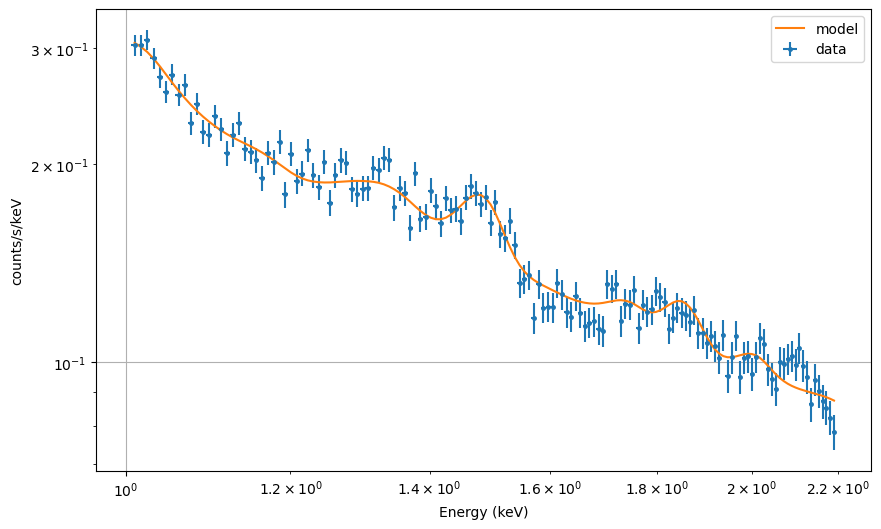

In [26]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  5
0
1
2
3
4


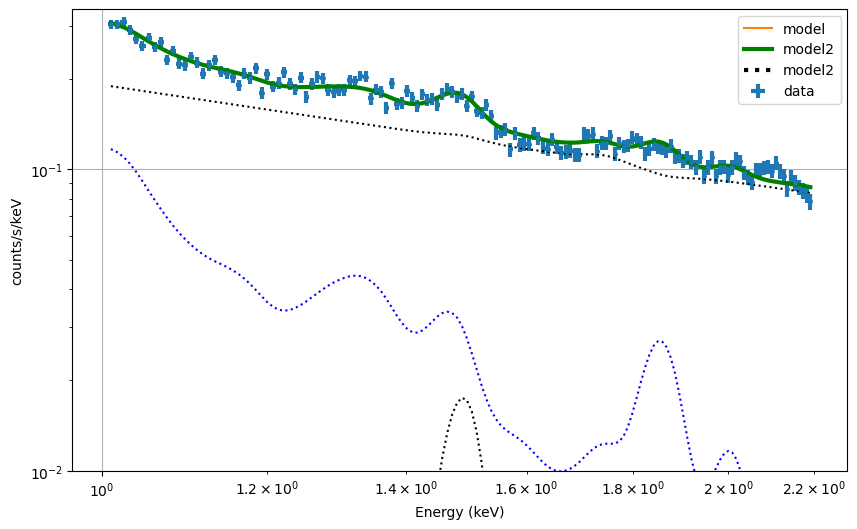

In [27]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model')
#2.14
ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

for i in range(0,2):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

for i in range(2,nAddComps):
    print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')

diff = foldedmodel - modelcomptot
ax.plot(energiesTMi, diff,label='model2',linestyle=':', marker='',color='black',linewidth=3.0)

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((0.01,0.34))
ax.grid()
ax.legend()

In [28]:
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=100000 #10000
Fit.perform()

In [29]:
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)
FTS = Fit.statistic
Fdof = Fit.dof 
Fpvalue = chi2.sf(FTS,Fdof)
print("TS ",Fit.statistic)
print("p-value ", Fpvalue)

Test Statistics  184.8915303987884  testStatistics  184.27283400724147  dof  139  nVarPars  6
TS  184.8915303987884
p-value  0.005604895809425642


In [30]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                  184.89     using 145 bins.

Test statistic : Chi-Squared                  184.27     using 145 bins.
 Null hypothesis probability of 6.12e-03 with 139 degrees of freedom


In [31]:
#Fit.goodness(1000)

In [32]:
#Fit.statMethod = "chi"  # fitting statistics = Cash-statistics
#Fit.nIterations=100000 #10000
#Fit.perform()

In [33]:
#print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)
#FTS = Fit.statistic
#Fdof = Fit.dof 
#Fpvalue = chi2.sf(FTS,Fdof)
#print("TS ",Fit.statistic)
#print("p-value ", Fpvalue)

In [34]:
#Xset.chatter = 10
#Fit.show()
#Xset.chatter = 1

# Detaprint(modelcomp[0][:])
print(modelcomp[1][:])
print(modelcomp[2][:])
#print(modelcomp[3][:])